/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9225 - loss: 0.2754
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9651 - loss: 0.1202
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0812
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9820 - loss: 0.0606
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0469
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0753
Test accuracy: 0.9772
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


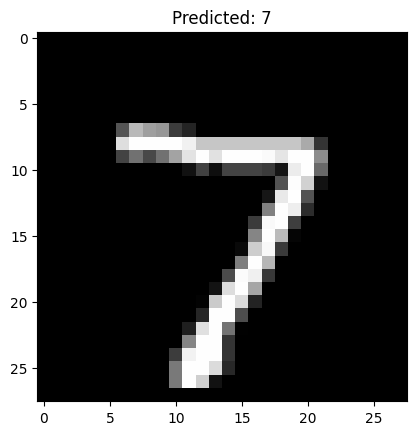

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

#load MNIST dataset

(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

#normalise data scale btwn 0 and 1
x_train,x_test=x_train/255.0,x_test/255.0
#build a simple neutral network model
model=keras.Sequential([
keras.layers.Flatten(input_shape=(28,28)),
keras.layers.Dense(128,activation='relu'),
keras.layers.Dense(19,activation='softmax')
])

#compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#train the model
model.fit(x_train,y_train,epochs=5)

#evaluate on test data
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'Test accuracy: {test_acc:.4f}')

#display sample predictions
predictions=model.predict(x_test)
plt.imshow(x_test[0],cmap='gray')
plt.title(f'Predicted: {predictions[0].argmax()}')
plt.show()



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9620 - loss: 0.1247 - val_accuracy: 0.9842 - val_loss: 0.0446
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9859 - loss: 0.0432 - val_accuracy: 0.9873 - val_loss: 0.0391
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9914 - loss: 0.0282 - val_accuracy: 0.9866 - val_loss: 0.0377
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9931 - loss: 0.0207 - val_accuracy: 0.9911 - val_loss: 0.0275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9947 - loss: 0.0153 - val_accuracy: 0.9910 - val_loss: 0.0293
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9910 - loss: 0.0293
Test accuracy: 0.9910
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


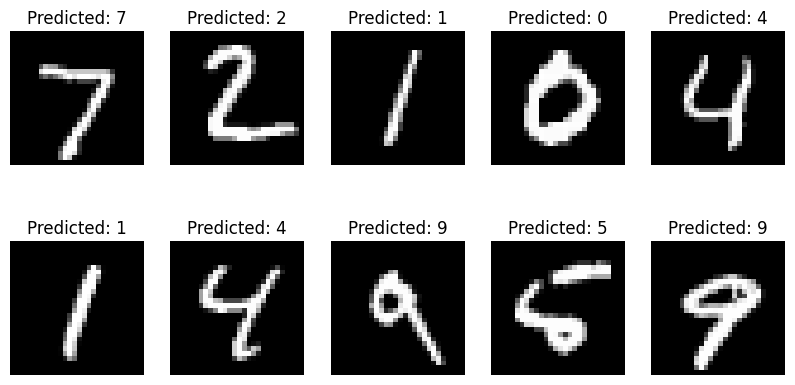

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

x_train,x_test=x_train/255.0,x_test/255.0

#reshape data to include channel dimension(28,28,1)
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

#define CNN model
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax') #10 classes for digits 0-9
])

#compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#train the model
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

#evaluate model
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'Test accuracy: {test_acc:.4f}')

#predict on test images
predictions=model.predict(x_test)

#plot some predictions
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title(f'Predicted: {predictions[i].argmax()}')
  plt.axis('off')
plt.show()
